In [1]:
%load_ext autoreload
%autoreload 2

# Test Set_Points
**se testean los metodos para la creación de puntos aleatorios basados en una distrbución**

In [2]:
from proximitygraphs.points import SetPoints
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import style
style.mpl_apply()

## uniform_square



In [6]:
square = SetPoints.uniform_square(n=200, dims = 3, seed=73)

In [10]:
import seaborn as sns
import matplotlib as mpl
from matplotlib import font_manager



# Use the exact family name recognized by Matplotlib
mpl.rcParams["font.family"] = "Cormorant Garamond"
mpl.rcParams["font.serif"]  = ["Cormorant Garamond", *mpl.rcParams["font.serif"]]

# Optional: math text will still use DejaVu; set only if you accept mixed math:
# mpl.rcParams["mathtext.rm"] = "Cormorant Garamond"

sns.set(
    style="whitegrid",
    palette="muted",
    font_scale=1.2,           # keep; don't use seaborn's `font=` here
    rc={
        "grid.linestyle": "--",
        "axes.edgecolor": "white",
        "axes.linewidth": 0.8,
        "grid.color": "lightgray",
        "figure.figsize": (8, 8),
        "axes.titlesize": 20,
        "axes.labelsize": 14,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "legend.title_fontsize": 10,
    },
)


(<Figure size 800x800 with 1 Axes>, <Axes: >)

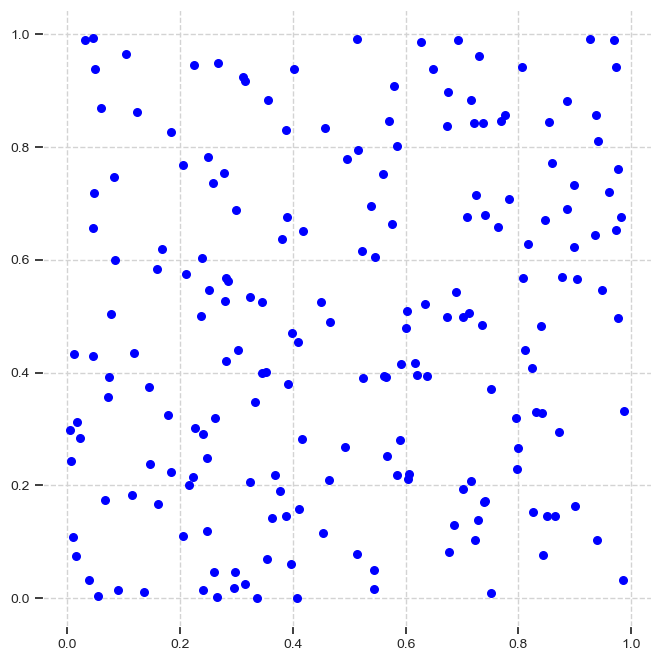

In [12]:
square.draw(figsize=(8, 8), color='blue', plot_axes=(0,2))

## uniform_over_sphere

(<Figure size 400x400 with 1 Axes>, <Axes: >)

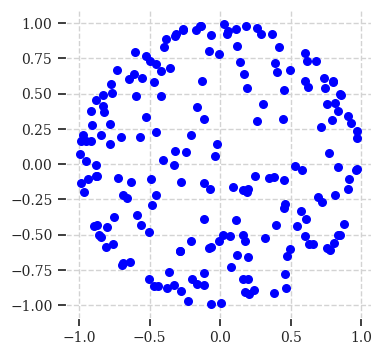

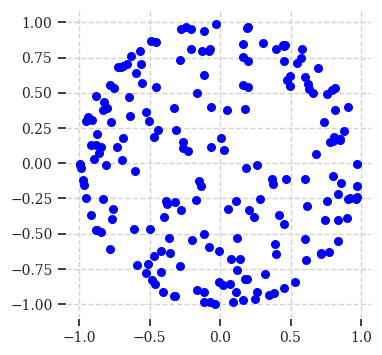

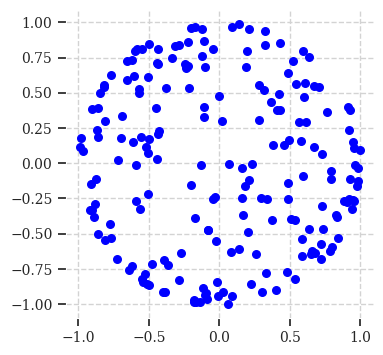

In [8]:
uniform_over_sphere = SetPoints.uniform_over_sphere(n=200, dims = 3, seed=0)


uniform_over_sphere.draw(figsize=(4, 4), color='blue', plot_axes=(0,1))
uniform_over_sphere.draw(figsize=(4, 4), color='blue', plot_axes=(0,2))
uniform_over_sphere.draw(figsize=(4, 4), color='blue', plot_axes=(1,2))


(<Figure size 800x800 with 1 Axes>, <Axes: >)

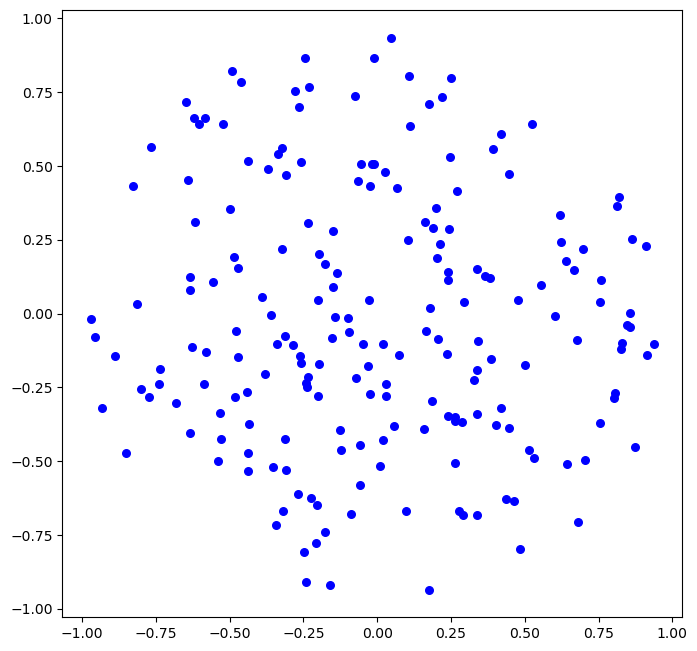

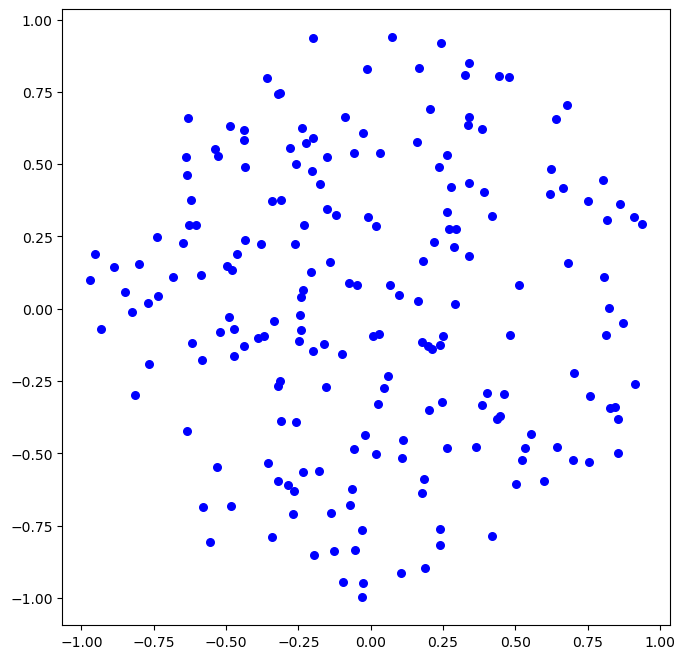

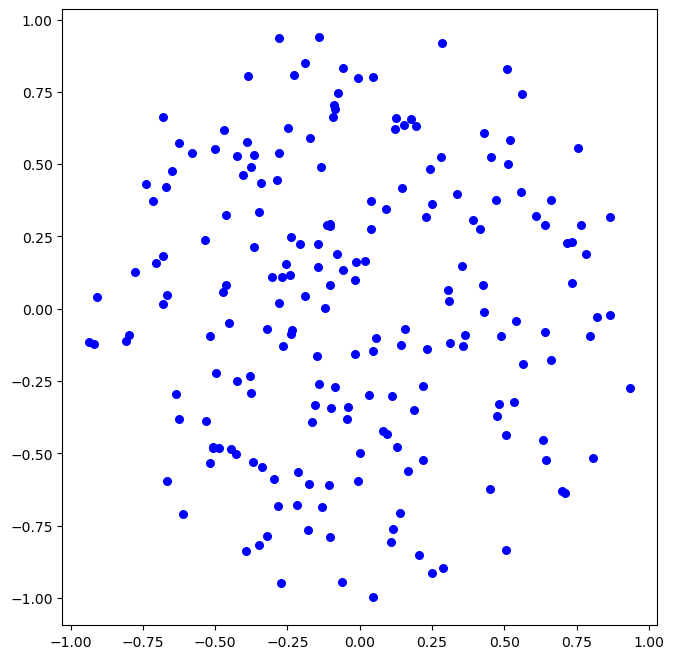

In [22]:
uniform_sphere = SetPoints.uniform_sphere(n=200, dims = 3, seed=0)
uniform_sphere.draw(figsize=(8, 8), color='blue', plot_axes=(0,1))
uniform_sphere.draw(figsize=(8, 8), color='blue', plot_axes=(0,2)) 
uniform_sphere.draw(figsize=(8, 8), color='blue', plot_axes=(1,2))

## Normal Distributed

(<Figure size 800x800 with 1 Axes>, <Axes: >)

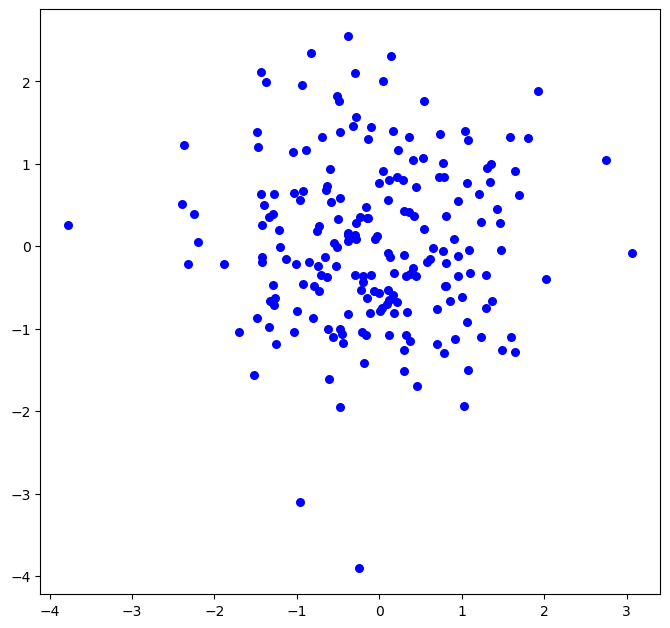

In [23]:
normal = SetPoints.normal_dist(n=200, dims = 3, seed=0)
normal.draw(figsize=(8, 8), color='blue', plot_axes=(0,1))
#normal.draw(figsize=(8, 8), color='blue', plot_axes=(0,2))
#normal.draw(figsize=(8, 8), color='blue', plot_axes=(1,2))

## Grids

(<Figure size 800x800 with 1 Axes>, <Axes: >)

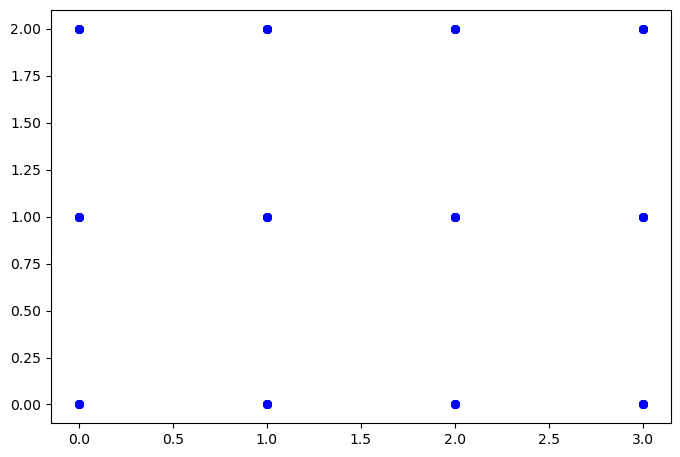

In [24]:
grids = SetPoints.grid(shape=(3,2,5))
grids.draw(figsize=(8, 8), color='blue', plot_axes=(0,1))
#grids.draw(figsize=(8, 8), color='blue', plot_axes=(0,2))
#grids.draw(figsize=(8, 8), color='blue', plot_axes=(1,2))

## Hexagonal

(<Figure size 800x800 with 1 Axes>, <Axes: >)

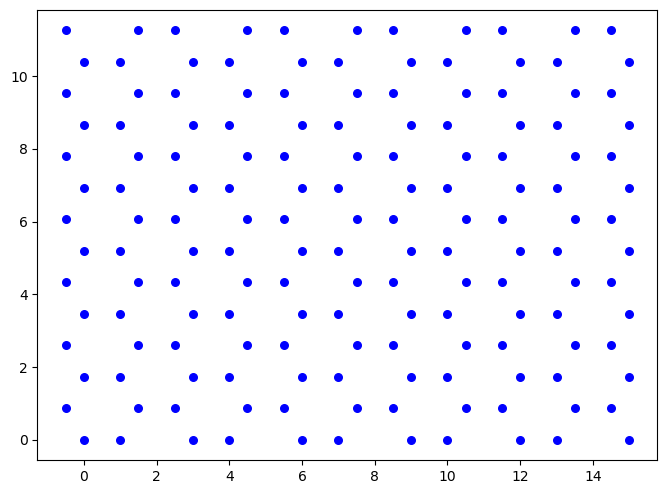

In [25]:
hexagon = SetPoints.hexagonal(n_x=5, n_y=3)

hexagon.draw(figsize=(8, 8), color='blue', plot_axes=(0,1))

(<Figure size 800x800 with 1 Axes>, <Axes: >)

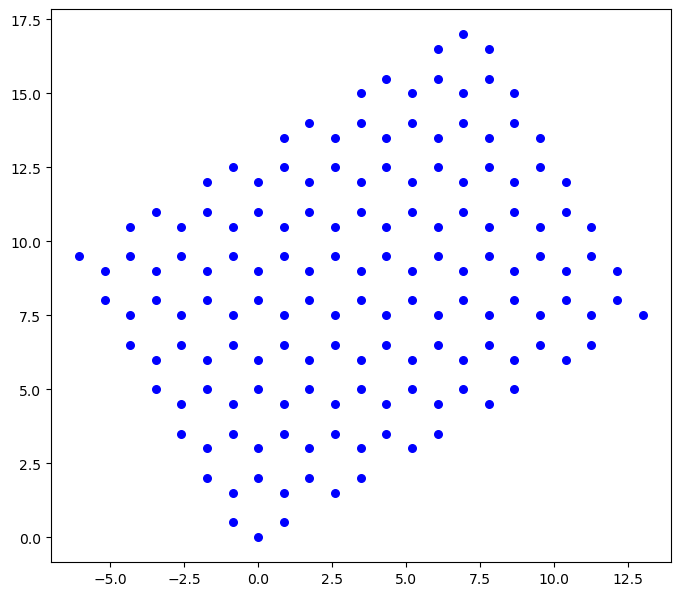

In [26]:
hexrotated = hexagon.rotation(degree=True, angle=30)
hexrotated.draw(figsize=(8, 8), color='blue')

(<Figure size 800x800 with 1 Axes>, <Axes: >)

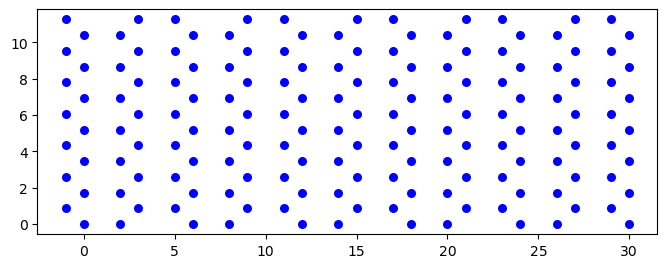

In [27]:
hexscaled = hexagon.scaling(scale = [2,1])
hexscaled.draw(figsize=(8, 8), color='blue')

(<Figure size 800x800 with 1 Axes>, <Axes: >)

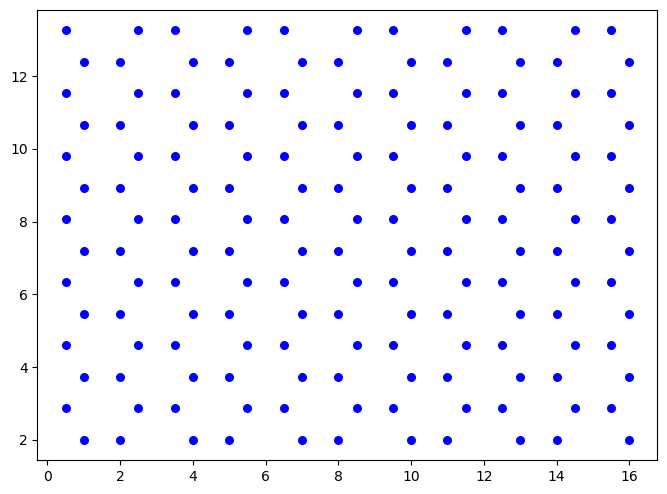

In [28]:
hextraslated = hexagon.traslation(c = [1,2])
hextraslated.draw(figsize=(8, 8), color='blue')

(<Figure size 800x800 with 1 Axes>, <Axes: >)

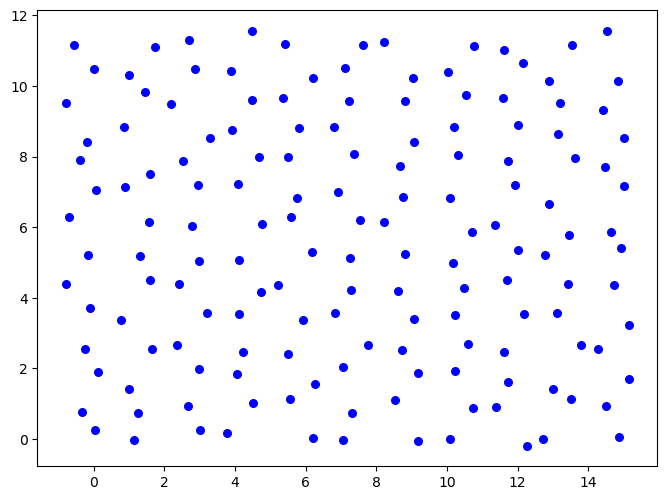

In [29]:
perturb = hexagon.perturb(radius=0.1)
perturb.draw(figsize=(8, 8), color='blue')

## Triangular 

(<Figure size 800x800 with 1 Axes>, <Axes: >)

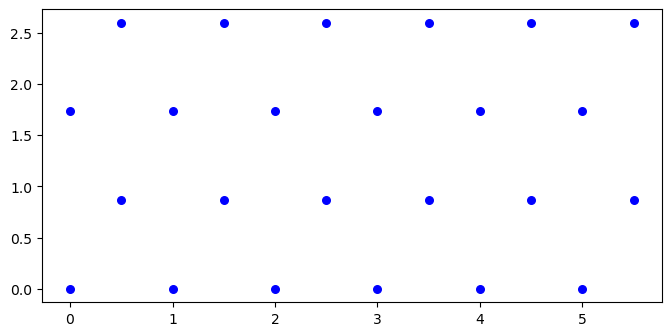

In [30]:
triangle = SetPoints.triangular(n_x=5, n_y=3)
triangle.draw(figsize=(8, 8), color='blue', plot_axes=(0,1))

## Poisson process

(<Figure size 800x800 with 1 Axes>, <Axes: >)

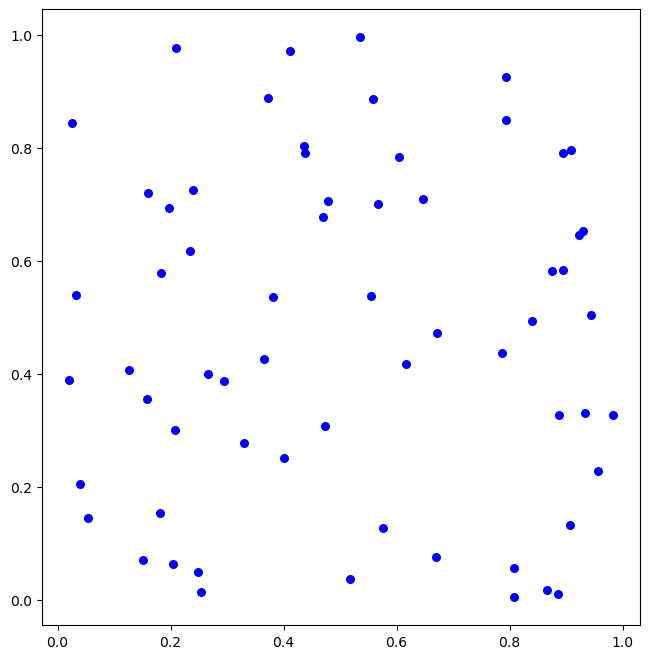

In [31]:
poisson = SetPoints.poissonprocess_square(intensity=50.5, limit=1)
poisson.draw(figsize=(8, 8), color='blue', plot_axes=(0,1))

## Poisson process Circle

(<Figure size 800x800 with 1 Axes>, <Axes: >)

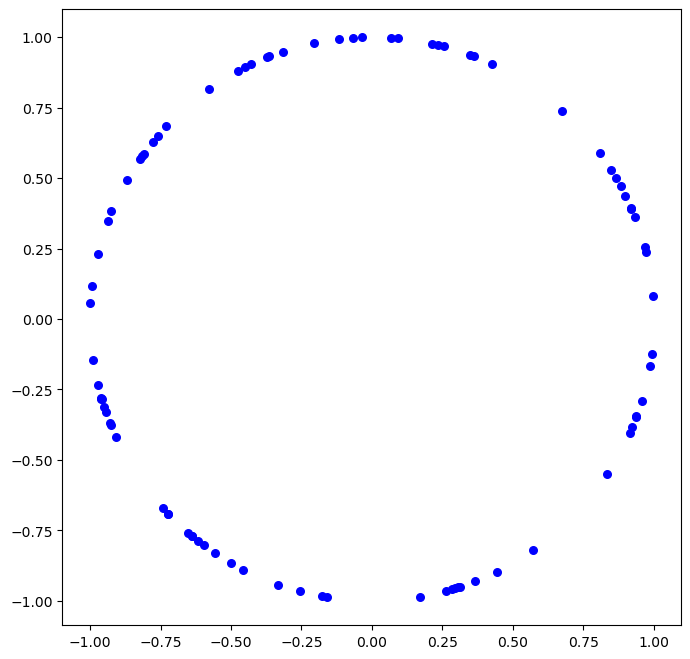

In [32]:
PoissCircle = SetPoints.poissonprocess_circle(intensity=10.5, radius=1)
PoissCircle.draw(figsize=(8, 8), color='blue')

# **draw2 method**

In [19]:
import proximitygraphs as pg
config = {
            'point_generator': {
                'name': 'normal_dist',
                'params': {'n': 500, 'dims': 2}
            },
            'transformations': [
                {
                    'name': 'perturb',
                    'params': {'radius': 0.25}
                }
            ],
            'graph': {
                'type': 'ProximityGraph',
                'name': 'Beta_Skeleton',
                'params': {'beta': 1.5}
            }
        }

points, graph = pg.Experiment(config).run()

In [34]:
# graph.draw(figsize=(6, 6), v_size=5, e_size=1, v_color='red', e_color='blue', title=True, details=True, fontsize=10)

In [31]:
vcolor = '#051650'
ecolor = '#0A2472'

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'β-Skeleton\nβ=1.5, closed=False, type=lune'}>)

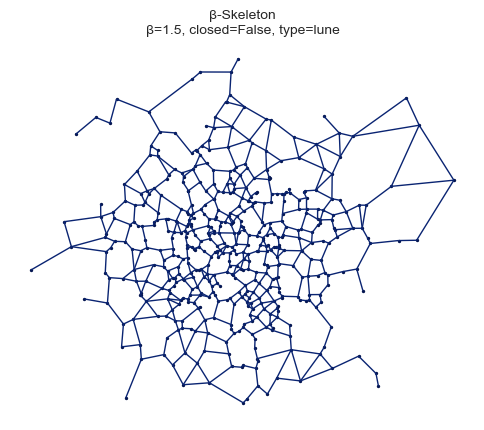

In [38]:
graph.draw2(figsize=(6, 6), v_size=2, e_size=1, v_alpha=1, e_alpha=1, v_color=vcolor, e_color=ecolor, title=True, details=True, fontsize=10)

# **Alpha Shape and Alpha Hull**

In [25]:
from proximitygraphs import Alpha_Hull, Alpha_Shape

In [26]:
uniform_sphere = SetPoints.uniform_sphere(n=200, dims = 2, seed=0)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Alpha-Hull\nalpha=-5'}>)

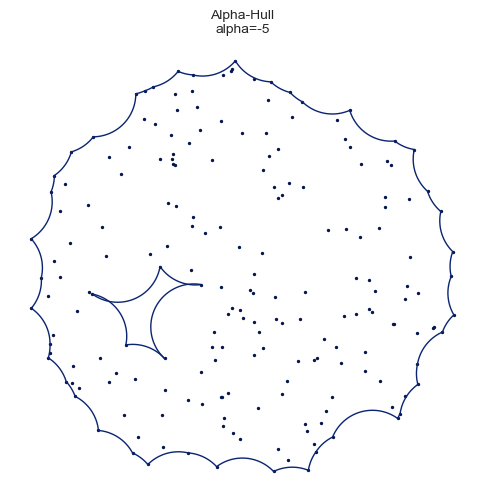

In [41]:

H = Alpha_Hull(uniform_sphere, alpha=-5, n_points_per_arc=50)
H.draw(title=True, details=True, figsize=(6,6), v_size=2, e_size=1, v_color=vcolor, e_color=ecolor, fontsize=10)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Delaunay Triangulation'}>)

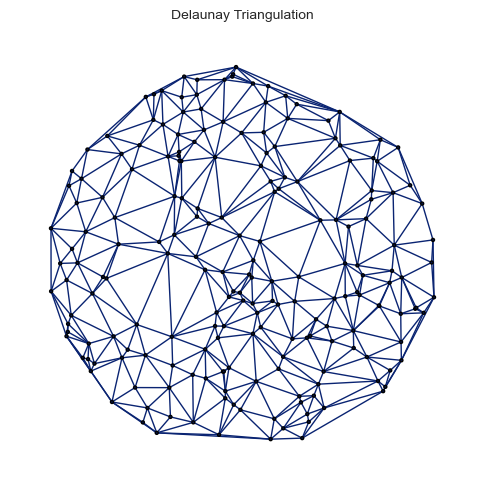

In [44]:
from proximitygraphs import DelaunayG


H = DelaunayG(uniform_sphere)
H.draw(title=True, details=True, figsize=(6,6), v_size=3, e_size=1, v_color=vcolor, e_color=ecolor, fontsize=10)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'β-Skeleton\nβ=1.5, closed=False, type=lune'}>)

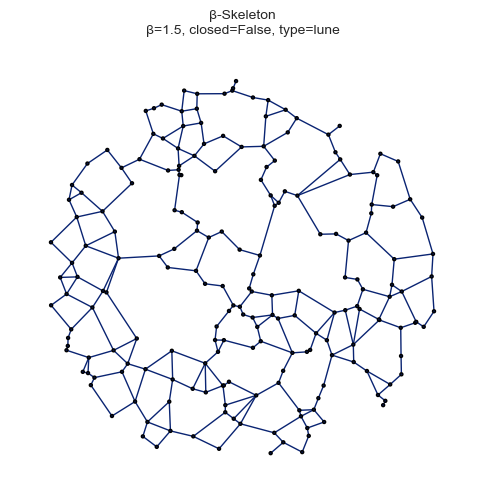

In [45]:
from proximitygraphs import Beta_Skeleton

H = Beta_Skeleton(uniform_sphere)
H.draw(title=True, details=True, figsize=(6,6), v_size=3, e_size=1, v_color=vcolor, e_color=ecolor, fontsize=10)

In [24]:
normal = SetPoints.normal_dist(n=100_000, dims = 2, seed=0)

In [25]:
H = Alpha_Shape(normal, alpha=0.00001)

(<Figure size 1500x1500 with 1 Axes>,
 <Axes: title={'center': 'Alpha-Shape\nalpha=1e-05'}>)

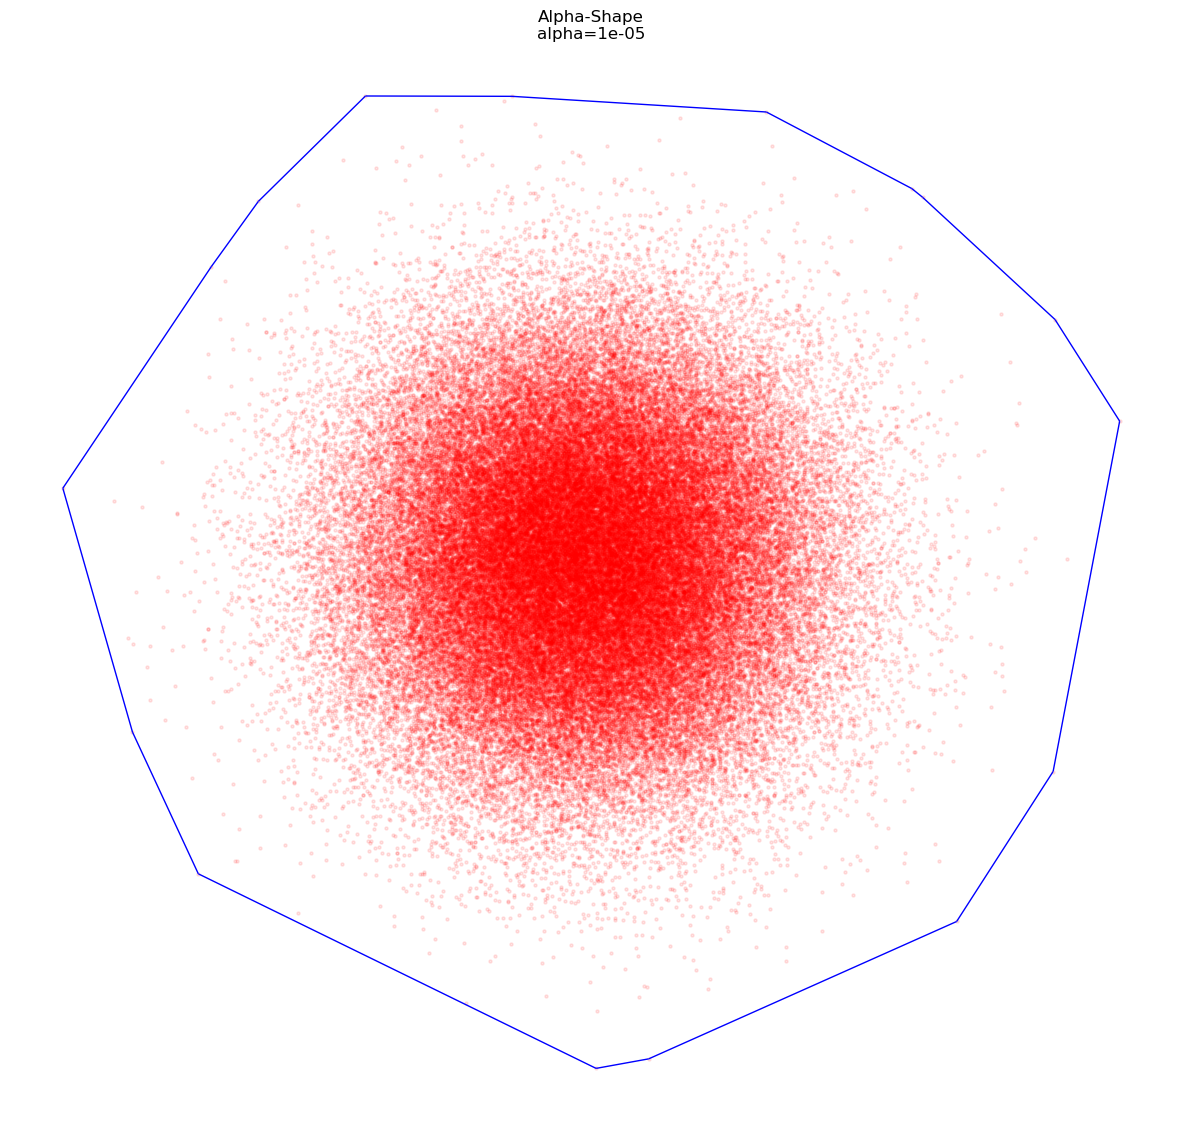

In [26]:
H.draw2(title=True, details=True, v_size=5, e_size=1, v_color='red', e_color='blue', v_alpha=0.1, e_alpha=1)

In [27]:
H = Alpha_Shape(normal, alpha=-4)

(<Figure size 1500x1500 with 1 Axes>,
 <Axes: title={'center': 'Alpha-Shape\nalpha=-4'}>)

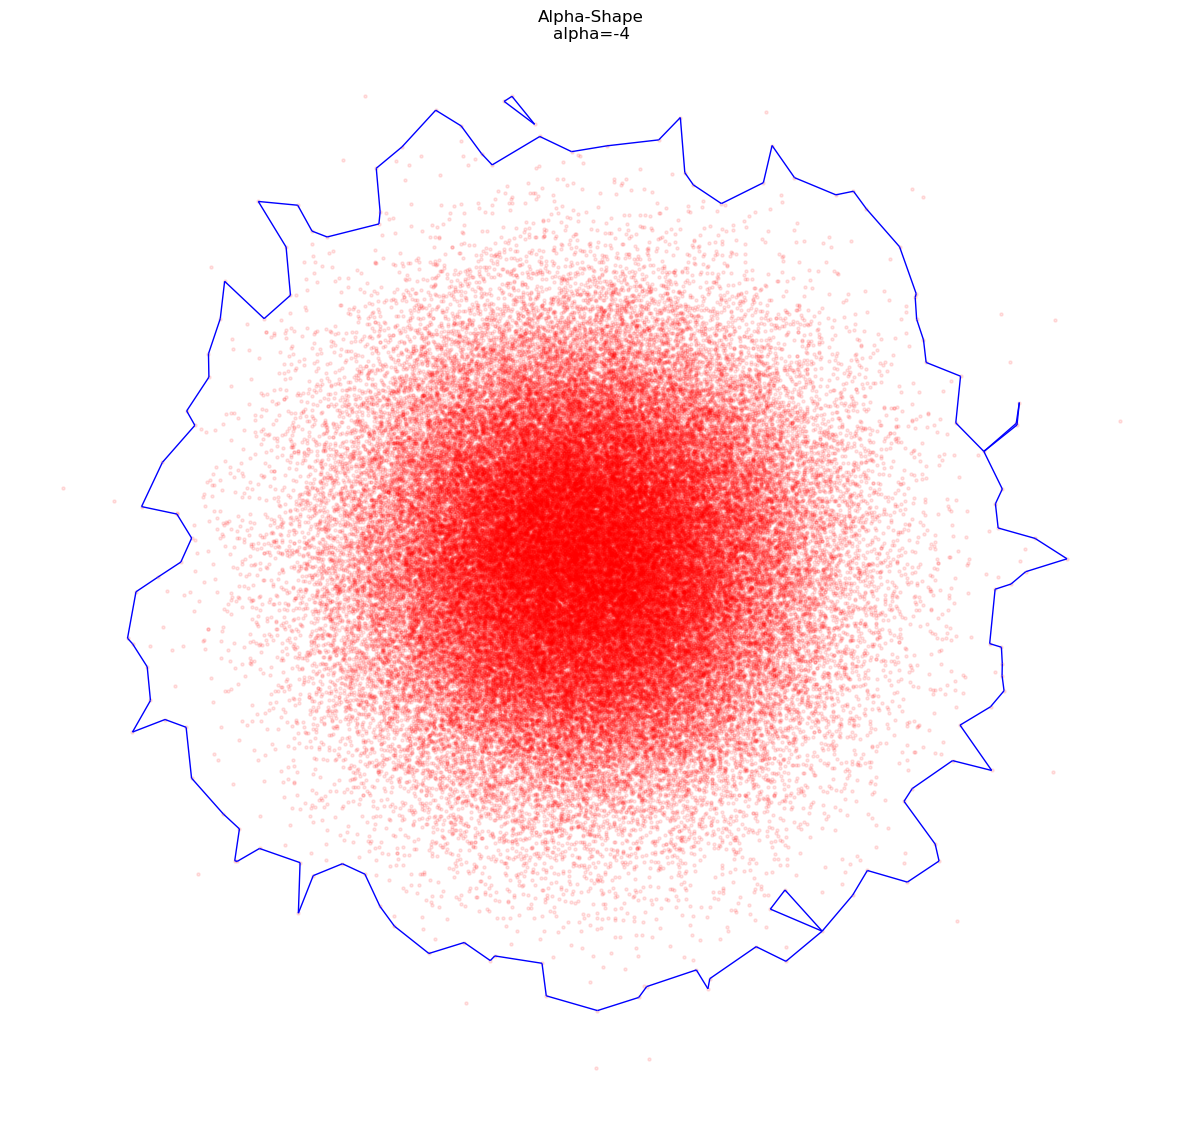

In [28]:
H.draw2(title=True, details=True, v_size=5, e_size=1, v_color='red', e_color='blue', v_alpha=0.1, e_alpha=1)